# Virtual Patient Diagnostics for Longitudinal HIV Immunology

Editable report notebook for the paper direction: diagnostic evaluation of virtual patient generation in a small-cohort longitudinal HIV immunology dataset.

This notebook is intentionally not a polished pipeline. It keeps the analysis in cells so tables, figures, feature blocks, generator settings, and wording can be tweaked for the manuscript.

## Framing

Use this as a diagnostic framework for data-driven virtual immune profiles. Do not frame the analysis as a mechanistic or multiscale immune model. The safe claim is that generators preserve or distort observed immune-feature structure and provided longitudinal response summaries.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()
if PROJECT.name == 'notebooks':
    PROJECT = PROJECT.parent
if PROJECT.name != 'data_synthesis':
    PROJECT = PROJECT / 'data_synthesis'

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.loaders import load_HIV
from models.bootstrap import sample_bootstrap
from models.iid_columnwise import sample_columnwise
from models.gmm import sample_gmm
from rfhack.core.metrics import run_many_rf_trials, tstr_f1, kld_per_feature, correlation_diff
from rfhack.core.rf_wrapper import RFWrapper

DATA = PROJECT / 'data'
RESULTS = PROJECT / 'notebooks' / 'virtual_patient_outputs'
RESULTS.mkdir(parents=True, exist_ok=True)

SEED = 42
N_RF_TRIALS = 10
N_NOISE_REPS = 10
SIGMAS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0]
RUN_CVAE = False
CVAE_EPOCHS = 200

plt.rcParams['figure.dpi'] = 120

## Load the existing HIV dataset

`load_HIV()` already existed and loads `data/allSyntheticData.RData`. The original R code created this from the MissForest-imputed 63-feature matrix.

In [2]:
hiv = load_HIV()
X = hiv['X']
y = hiv['y']
feature_names = list(hiv['feature_names'])

n0 = int((y == 0).sum())
n1 = int((y == 1).sum())

print(hiv['dataset'], X.shape)
print({'class_0': n0, 'class_1': n1})
pd.DataFrame({'idx': range(1, len(feature_names) + 1), 'feature': feature_names}).head(15)

HIV (91, 63)
{'class_0': 23, 'class_1': 68}


,idx,feature
0,1,spikeProduction_D1D2
1,2,spikeDecay_D1D2
2,3,spikeProduction_D3
3,4,spikeDecay_D3
4,5,RBDProduction_D1D2
5,6,RBDDecay_D1D2
6,7,RBDProduction_D3
7,8,RBDDecay_D3
8,9,V1_blood_IgGspike
9,10,V4_blood_IgGspike


## Optional: inspect the source CSV

This is useful for report provenance. The first column is a participant index (`1..91`), not a real participant ID.

In [3]:
feature_csv = DATA / 'features_withMissForestImputation_IR_INR_together_jul25_63Features.csv'
feature_df = pd.read_csv(feature_csv)
feature_df = feature_df.rename(columns={feature_df.columns[0]: 'participant_index'})

print(feature_csv)
print(feature_df.shape)
print('participant index unique:', feature_df['participant_index'].is_unique)
print('missing values:', int(feature_df.isna().sum().sum()))
feature_df.head()

c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\data\features_withMissForestImputation_IR_INR_together_jul25_63Features.csv
(91, 64)
participant index unique: True
missing values: 0


,participant_index,spikeProduction_D1D2,spikeDecay_D1D2,spikeProduction_D3,spikeDecay_D3,RBDProduction_D1D2,RBDDecay_D1D2,RBDProduction_D3,RBDDecay_D3,V1_blood_IgGspike,...,V8Dual,IFNG_production,Il2_production,RATIO_CD4CD8,V8Neut,V9Neut,V7_ACE2,V8_ACE2,V8b_ACE2,V9_ACE2
0,1,3.02619,0.026202,0.625745,0.008606,2.38407,0.021537,0.805338,0.011502,46.40,...,3.650,0.029383,0.141349,1.200000,640.0,160.0,120.45,50.06,290.15,51.83
1,2,3.14163,0.023697,0.628603,0.008465,2.42953,0.021465,0.836061,0.011243,1.45,...,2.500,0.028455,0.084624,1.200000,331.7,308.8,290.15,180.57,210.99,336.44
2,3,3.20550,0.024468,0.626565,0.008584,2.42524,0.021580,0.819237,0.011380,1.80,...,5.000,0.003646,0.119137,4.733333,640.0,359.6,351.14,196.09,942.25,227.66
3,4,3.25611,0.024539,0.622260,0.008692,2.48369,0.021546,0.836927,0.011226,8.84,...,5.375,0.025559,0.119593,1.200000,165.8,2560.0,290.15,190.37,311.89,1520.29
4,5,3.12675,0.025165,0.623358,0.008591,2.30427,0.021659,0.823209,0.011209,18.33,...,2.500,0.036871,0.138498,1.666667,617.5,160.0,191.82,50.06,1518.65,290.15


## Define generators

CVAE is optional because it can take longer and requires torch. Toggle `RUN_CVAE = True` in the setup cell when needed.

In [4]:
generators = {
    'bootstrap': lambda seed: sample_bootstrap(X, y, n0, n1, seed=seed),
    'columnwise': lambda seed: sample_columnwise(X, y, n0, n1, seed=seed),
    'gmm': lambda seed: sample_gmm(X, y, n0, n1, seed=seed),
}

if RUN_CVAE:
    from util.config import Config
    from models.cvae import train_cvae, sample_trained_cvae
    cfg = Config(seed=SEED, epochs=CVAE_EPOCHS)
    cvae_state = train_cvae(X, y, cfg=cfg, verbose=True)
    generators['cvae'] = lambda seed: sample_trained_cvae(cvae_state, n0, n1, seed=seed)

synthetic = {method: gen(SEED) for method, gen in generators.items()}
list(synthetic)

['bootstrap', 'columnwise', 'gmm']

## Result 1: synthetic immune profiles are distinguishable across generation mechanisms

In [5]:
rows = []
for method, (X_syn, y_syn) in synthetic.items():
    rf = run_many_rf_trials(X, y, X_syn, y_syn, trials=N_RF_TRIALS)
    util = tstr_f1(X, y, X_syn, y_syn)
    kld = kld_per_feature(X, X_syn)
    corr = correlation_diff(X, X_syn)
    rows.append({
        'method': method,
        'n_real': len(X),
        'n_synthetic': len(X_syn),
        'n_features': X.shape[1],
        **rf,
        **util,
        'kld_mean': kld['kld_mean'],
        'kld_max': kld['kld_max'],
        **corr,
    })

distinguishability = pd.DataFrame(rows).sort_values('rf_sep_mean', ascending=False)
distinguishability.to_csv(RESULTS / 'hiv_distinguishability.csv', index=False)
distinguishability

  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10


,method,n_real,n_synthetic,n_features,rf_auc_mean,rf_auc_sd,rf_sep_mean,rf_sep_sd,disc_f1_mean,disc_f1_sd,tstr_f1,trtr_f1,utility_gap,kld_mean,kld_max,corr_mean_abs_diff,corr_max_abs_diff
2,gmm,91,91,63,0.941556,0.033036,0.941556,0.033036,0.868231,0.072480,0.978417,0.970799,-0.007618,1.109526,2.613460,0.095254,0.902218
0,bootstrap,91,91,63,0.358667,0.073112,0.641333,0.073112,0.424079,0.079883,0.964029,0.970799,0.006771,0.693525,1.912173,0.063260,0.337657
1,columnwise,91,91,63,0.513556,0.157507,0.621111,0.101608,0.497385,0.178014,0.978417,0.970799,-0.007618,0.622542,1.670809,0.294860,1.029464


## Result 2: noise-response curves reveal generator-specific failure signatures

In [6]:
def add_scaled_noise(X_syn, sigma, seed):
    if sigma <= 0:
        return np.asarray(X_syn, dtype=float).copy()
    std = X.std(axis=0)
    std = np.where(std == 0, 1.0, std)
    rng = np.random.default_rng(seed)
    return np.asarray(X_syn, dtype=float) + rng.standard_normal(X_syn.shape) * std * sigma

def rf_separability(X_real, X_syn):
    cols = [f'f{i}' for i in range(X_real.shape[1])]
    real = pd.DataFrame(X_real, columns=cols)
    syn = pd.DataFrame(X_syn, columns=cols)
    real['target'] = 1
    syn['target'] = 0
    avg, mn, mx = RFWrapper.from_combined(pd.concat([real, syn], ignore_index=True), test_size=0.3)
    return max(avg, 1.0 - avg), mn, mx

noise_rows = []
for method, gen in generators.items():
    for sigma in SIGMAS:
        vals = []
        for rep in range(N_NOISE_REPS):
            rep_seed = SEED + rep
            X_syn, _ = gen(rep_seed)
            X_noisy = add_scaled_noise(X_syn, sigma=sigma, seed=rep_seed + 500)
            sep, sep_min, sep_max = rf_separability(X, X_noisy)
            vals.append(sep)
            noise_rows.append({'method': method, 'sigma': sigma, 'rep': rep, 'sep': sep, 'sep_min': sep_min, 'sep_max': sep_max})

noise = pd.DataFrame(noise_rows)
noise_summary = noise.groupby(['method', 'sigma'], as_index=False).agg(sep_mean=('sep', 'mean'), sep_sd=('sep', 'std'))
noise.to_csv(RESULTS / 'hiv_noise_sweep_reps.csv', index=False)
noise_summary.to_csv(RESULTS / 'hiv_noise_sweep.csv', index=False)
noise_summary.head()

,method,sigma,sep_mean,sep_sd
0,bootstrap,0.00,0.701574,0.028115
1,bootstrap,0.05,0.809134,0.048190
2,bootstrap,0.10,0.880926,0.038878
3,bootstrap,0.20,0.965522,0.021585
4,bootstrap,0.30,0.989081,0.010803


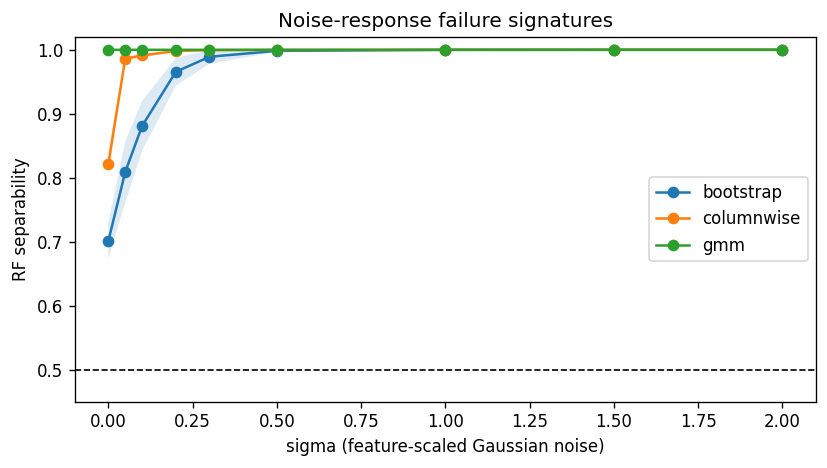

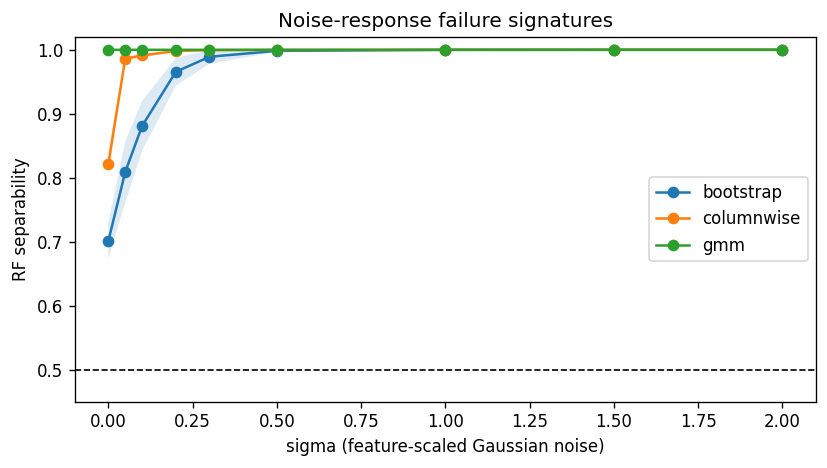

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for method, sub in noise_summary.groupby('method'):
    sub = sub.sort_values('sigma')
    ax.plot(sub['sigma'], sub['sep_mean'], marker='o', label=method)
    ax.fill_between(sub['sigma'], sub['sep_mean'] - sub['sep_sd'].fillna(0), sub['sep_mean'] + sub['sep_sd'].fillna(0), alpha=0.15)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('sigma (feature-scaled Gaussian noise)')
ax.set_ylabel('RF separability')
ax.set_ylim(0.45, 1.02)
ax.legend()
ax.set_title('Noise-response failure signatures')
fig.tight_layout()
fig.savefig(RESULTS / 'hiv_noise_response.png')
fig

## Result 3: biological block analysis localizes immune structures driving distinguishability

In [8]:
blocks = {
    'antibody_kinetics': [c for c in feature_names if c in [
        'spikeProduction_D1D2', 'spikeDecay_D1D2', 'spikeProduction_D3', 'spikeDecay_D3',
        'RBDProduction_D1D2', 'RBDDecay_D1D2', 'RBDProduction_D3', 'RBDDecay_D3']],
    'serum_igg_spike': [c for c in feature_names if c.endswith('_blood_IgGspike')],
    'serum_igg_rbd': [c for c in feature_names if c.endswith('_blood_IgGRBD')],
    'saliva_igg': [c for c in feature_names if '_Saliva_IgG' in c],
    'saliva_iga': [c for c in feature_names if '_Saliva_IgA' in c],
    't_cell_cytokine': [c for c in feature_names if c in ['V8_IFNg', 'V9_IFNg', 'V8_IL2', 'V9_IL2', 'V8Dual', 'V9Dual', 'IFNG_production', 'Il2_production']],
    'cd4_neutrophil_context': [c for c in feature_names if c in ['RATIO_CD4CD8', 'V8Neut', 'V9Neut']],
    'ace2_neutralization': [c for c in feature_names if c in ['V7_ACE2', 'V8_ACE2', 'V8b_ACE2', 'V9_ACE2']],
}

seen = [c for cols in blocks.values() for c in cols]
assert sorted(seen) == sorted(feature_names), sorted(set(feature_names) - set(seen))
pd.DataFrame({'block': list(blocks), 'n_features': [len(v) for v in blocks.values()]})

,block,n_features
0,antibody_kinetics,8
1,serum_igg_spike,10
2,serum_igg_rbd,10
3,saliva_igg,10
4,saliva_iga,10
5,t_cell_cytokine,8
6,cd4_neutrophil_context,3
7,ace2_neutralization,4


In [9]:
name_to_idx = {name: i for i, name in enumerate(feature_names)}

block_rows = []
for block, cols in blocks.items():
    idx = [name_to_idx[c] for c in cols]
    for method, (X_syn, y_syn) in synthetic.items():
        rf = run_many_rf_trials(X[:, idx], y, X_syn[:, idx], y_syn, trials=N_RF_TRIALS)
        kld = kld_per_feature(X[:, idx], X_syn[:, idx])
        block_rows.append({'block': block, 'method': method, 'n_features': len(idx), **rf, 'kld_mean': kld['kld_mean'], 'kld_max': kld['kld_max']})

block_results = pd.DataFrame(block_rows).sort_values(['method', 'rf_sep_mean'], ascending=[True, False])
block_results.to_csv(RESULTS / 'hiv_block_only.csv', index=False)
block_results

  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10
  RF trial 1/10
  RF trial 10/10


,block,method,n_features,rf_auc_mean,rf_auc_sd,rf_sep_mean,rf_sep_sd,disc_f1_mean,disc_f1_sd,kld_mean,kld_max
9,saliva_igg,bootstrap,10,0.373333,0.111462,0.652889,0.071366,0.432762,0.098528,0.793619,1.433590
12,saliva_iga,bootstrap,10,0.357333,0.097762,0.650667,0.084916,0.428103,0.091713,0.485817,0.762826
15,t_cell_cytokine,bootstrap,8,0.374000,0.074304,0.630444,0.066191,0.460789,0.067312,0.708728,1.304179
21,ace2_neutralization,bootstrap,4,0.376444,0.078178,0.623556,0.078178,0.415323,0.072536,0.780965,1.349391
6,serum_igg_rbd,bootstrap,10,0.399556,0.106271,0.621778,0.080950,0.406034,0.126410,0.555051,1.122045
0,antibody_kinetics,bootstrap,8,0.390000,0.106022,0.618889,0.095949,0.434188,0.128687,0.966258,1.912173
18,cd4_neutrophil_context,bootstrap,3,0.420667,0.094673,0.610000,0.056185,0.439906,0.112491,0.387668,0.763517
3,serum_igg_spike,bootstrap,10,0.408444,0.103689,0.607556,0.086981,0.440605,0.104165,0.766043,1.154566
10,saliva_igg,columnwise,10,0.694222,0.112464,0.694222,0.112464,0.621980,0.099224,0.591663,1.166419
22,ace2_neutralization,columnwise,4,0.690444,0.109351,0.690444,0.109351,0.664885,0.087010,0.951267,1.313179


## Result 4: clinical-context join audit

This cell checks whether `patient.xlsx` can be joined to the participant-level 63-feature matrix. It does not assign metadata to synthetic rows.

In [11]:
patient_path = DATA / 'patient.xlsx'
patient_raw = pd.read_excel(patient_path, sheet_name='Sheet1')
patient_participant = patient_raw.loc[patient_raw['#'].notna()].copy()
patient_participant = patient_participant.rename(columns={'#': 'participant_index'})
patient_participant['participant_index'] = patient_participant['participant_index'].astype(int)

feature_keys = feature_df['participant_index'].astype(int)
patient_keys = patient_participant['participant_index'].astype(int)

join_audit = {
    'feature_rows': len(feature_df),
    'patient_raw_rows': len(patient_raw),
    'patient_participant_rows': len(patient_participant),
    'feature_unique_keys': feature_keys.nunique(),
    'patient_unique_keys': patient_keys.nunique(),
    'keys_equal_as_sets': set(feature_keys) == set(patient_keys),
    'keys_equal_in_order': feature_keys.tolist() == patient_keys.tolist(),
    'participant_id_unique': patient_participant["Participant's ID"].nunique(),
    'participant_id_missing': int(patient_participant["Participant's ID"].isna().sum()),
}

status_col = 'HIV status: HIV Neg = 0, IR=1, INR=2, LLV=3, LTNP=4'
status_counts = patient_participant[status_col].value_counts(dropna=False).sort_index()

pd.DataFrame([join_audit]).to_csv(RESULTS / 'hiv_clinical_join_audit.csv', index=False)
print(join_audit)
status_counts

{'feature_rows': 91, 'patient_raw_rows': 1311, 'patient_participant_rows': 91, 'feature_unique_keys': 91, 'patient_unique_keys': 91, 'keys_equal_as_sets': True, 'keys_equal_in_order': True, 'participant_id_unique': 91, 'participant_id_missing': 0}


HIV status: HIV Neg = 0, IR=1, INR=2, LLV=3, LTNP=4
0.0    23
1.0    42
2.0    20
3.0     5
4.0     1
Name: count, dtype: int64

## Manuscript guardrails

- Do not merge raw visit rows onto participant-level features.
- Do not use immune assay columns from `patient.xlsx` as conditioning variables if they duplicate the 63 features.
- HIV-negative vs PLWH is the safest clinical comparison. IR vs INR is exploratory. LLV and LTNP are too small for strong claims.
- Treat production/decay features as provided longitudinal antibody-dynamic summaries unless original formula code is found.